In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('lte_5g_kpi.csv')
data.head()

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput
0,2024-01-01 00:00:00,-92.516429,-8.147645,21.996777,6.556722,39.872326
1,2024-01-01 01:00:00,-95.691322,-6.181167,19.623168,3.897629,47.832220
2,2024-01-01 02:00:00,-91.761557,-12.797135,15.298152,3.363602,38.113701
3,2024-01-01 03:00:00,-87.384851,-8.874062,11.765316,4.993251,45.380577
4,2024-01-01 04:00:00,-96.170767,-11.301285,18.491117,4.659631,21.595780


In [3]:
data.shape

(500, 6)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Timestamp   500 non-null    object 
 1   RSRP        500 non-null    float64
 2   RSRQ        500 non-null    float64
 3   SINR        500 non-null    float64
 4   BLER        500 non-null    float64
 5   Throughput  500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


In [5]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Timestamp   500 non-null    datetime64[ns]
 1   RSRP        500 non-null    float64       
 2   RSRQ        500 non-null    float64       
 3   SINR        500 non-null    float64       
 4   BLER        500 non-null    float64       
 5   Throughput  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 23.6 KB


In [7]:
data.head()

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput
0,2024-01-01 00:00:00,-92.516429,-8.147645,21.996777,6.556722,39.872326
1,2024-01-01 01:00:00,-95.691322,-6.181167,19.623168,3.897629,47.832220
2,2024-01-01 02:00:00,-91.761557,-12.797135,15.298152,3.363602,38.113701
3,2024-01-01 03:00:00,-87.384851,-8.874062,11.765316,4.993251,45.380577
4,2024-01-01 04:00:00,-96.170767,-11.301285,18.491117,4.659631,21.595780


In [8]:
data.isnull().sum()

Timestamp     0
RSRP          0
RSRQ          0
SINR          0
BLER          0
Throughput    0
dtype: int64

In [9]:
data[data.duplicated()]

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput


In [10]:
data['Timestamp'] = data['Timestamp'].reset_index(drop=True)


In [11]:
data.head()

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput
0,2024-01-01 00:00:00,-92.516429,-8.147645,21.996777,6.556722,39.872326
1,2024-01-01 01:00:00,-95.691322,-6.181167,19.623168,3.897629,47.832220
2,2024-01-01 02:00:00,-91.761557,-12.797135,15.298152,3.363602,38.113701
3,2024-01-01 03:00:00,-87.384851,-8.874062,11.765316,4.993251,45.380577
4,2024-01-01 04:00:00,-96.170767,-11.301285,18.491117,4.659631,21.595780


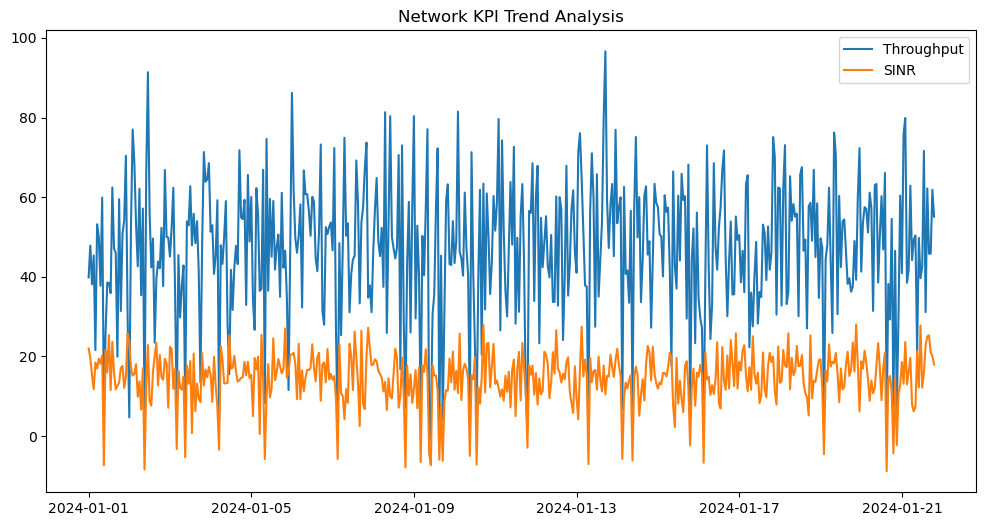

In [12]:
plt.figure(figsize=(12,6))
plt.plot(data['Timestamp'], data['Throughput'], label='Throughput')
plt.plot(data['Timestamp'], data['SINR'], label='SINR')
plt.legend()
plt.title("Network KPI Trend Analysis")
plt.show()


In [13]:
data['RSRP_RSRQ_Ratio'] = data['RSRP']/data['RSRQ']
data['Thrughput per SINR'] = data['Throughput']/ (data['SINR']+1)

In [14]:
data.head()

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput,RSRP_RSRQ_Ratio,Thrughput per SINR
0,2024-01-01 00:00:00,-92.516429,-8.147645,21.996777,6.556722,39.872326,11.354990,1.733822
1,2024-01-01 01:00:00,-95.691322,-6.181167,19.623168,3.897629,47.832220,15.481110,2.319344
2,2024-01-01 02:00:00,-91.761557,-12.797135,15.298152,3.363602,38.113701,7.170477,2.338529
3,2024-01-01 03:00:00,-87.384851,-8.874062,11.765316,4.993251,45.380577,9.847222,3.554990
4,2024-01-01 04:00:00,-96.170767,-11.301285,18.491117,4.659631,21.595780,8.509720,1.107981


In [15]:
Feature = data.drop(columns=['Timestamp'])

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Feature)

In [ ]:
# Anamoly Detection

In [17]:
from sklearn.ensemble import IsolationForest

features = data[['Throughput', 'SINR']]

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

data['Anomaly'] = model.fit_predict(features)

# Convert output
data['Anomaly'] = data['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})


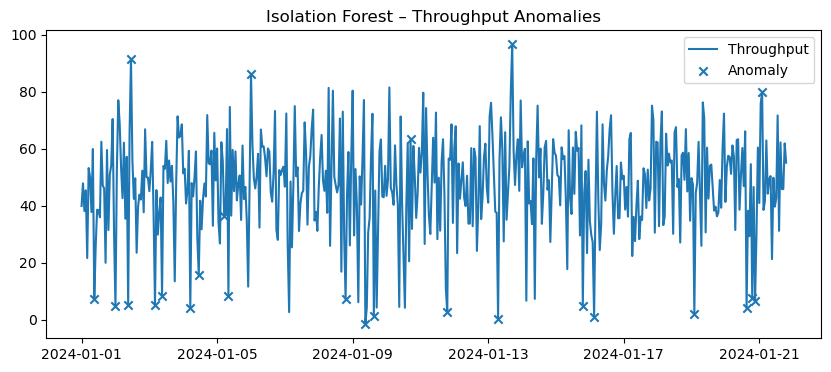

In [18]:
anomalies = data[data['Anomaly'] == 'Anomaly']

plt.figure(figsize=(10,4))
plt.plot(data['Timestamp'], data['Throughput'], label='Throughput')
plt.scatter(anomalies['Timestamp'], anomalies['Throughput'],
            marker='x', label='Anomaly')
plt.legend()
plt.title('Isolation Forest – Throughput Anomalies')
plt.show()


In [19]:
Z_scores = np.abs((data['Throughput']-data['Throughput'].mean())/data['Throughput'])
data['stat_anamoly'] = Z_scores > 3

In [20]:
data.head()

,Timestamp,RSRP,RSRQ,SINR,BLER,Throughput,RSRP_RSRQ_Ratio,Thrughput per SINR,Anomaly,stat_anamoly
0,2024-01-01 00:00:00,-92.516429,-8.147645,21.996777,6.556722,39.872326,11.354990,1.733822,Normal,False
1,2024-01-01 01:00:00,-95.691322,-6.181167,19.623168,3.897629,47.832220,15.481110,2.319344,Normal,False
2,2024-01-01 02:00:00,-91.761557,-12.797135,15.298152,3.363602,38.113701,7.170477,2.338529,Normal,False
3,2024-01-01 03:00:00,-87.384851,-8.874062,11.765316,4.993251,45.380577,9.847222,3.554990,Normal,False
4,2024-01-01 04:00:00,-96.170767,-11.301285,18.491117,4.659631,21.595780,8.509720,1.107981,Normal,False


In [22]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

data['ML_Anomaly'] = iso_forest.fit_predict(X_scaled)
data['ML_Anomaly'] = data['ML_Anomaly'].map({1: 0, -1: 1})


In [24]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=10)
data['DBSCAN_Anomaly'] = dbscan.fit_predict(X_scaled)
data['DBSCAN_Anomaly'] = data['DBSCAN_Anomaly'].apply(lambda x: 1 if x == -1 else 0)


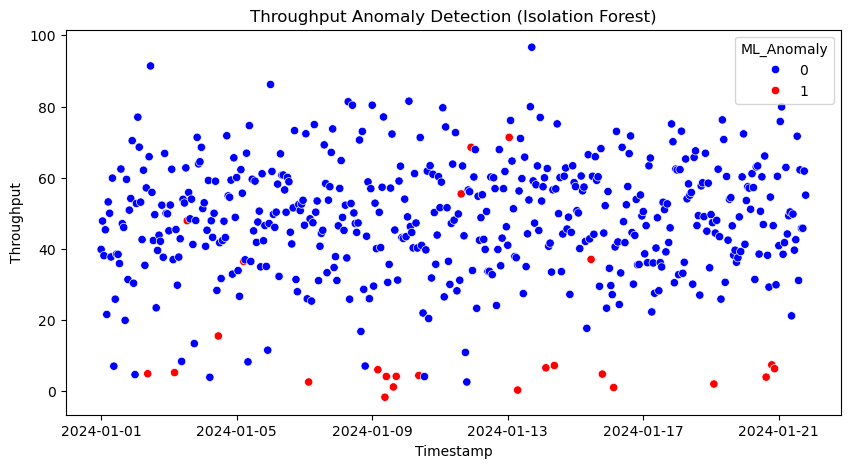

In [26]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=data['Timestamp'],
    y=data['Throughput'],
    hue=data['ML_Anomaly'],
    palette={0: 'blue', 1: 'red'}
)
plt.title("Throughput Anomaly Detection (Isolation Forest)")
plt.show()


In [28]:
print("Total Records:", len(data))
print("Statistical Anomalies:", data['stat_anamoly'].sum())
print("ML Anomalies:", data['ML_Anomaly'].sum())
print("DBSCAN Anomalies:", data['DBSCAN_Anomaly'].sum())


Total Records: 500
Statistical Anomalies: 28
ML Anomalies: 25
DBSCAN Anomalies: 37
